In [ ]:
import zipfile

zip_file_path = "BUSI_Jpeg (1).zip"
extract_dir = "BUSI_Jpeg"
Path(extract_dir).mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print(f"Extracted {zip_file_path} to {extract_dir}/")


Extracted BUSI_Jpeg (1).zip to BUSI_Jpeg/


Using existing cropped dataset at cropped_dataset/

  DATA SPLIT (Stratified 80/20)
  Set         Total   Benign  Malignant
  ────────────────────────────────────
  Train         517      349        168
  Test          130       88         42

  Model parameters: 102,081
  Device: cuda

  TRAINING
  Epoch  Time  Train Loss  Train Acc         LR
  ---------------------------------------------
    1      1s       0.6387       0.660   5.00e-04  |  test_acc: 0.677 ← saved
    2      1s       0.5968       0.675   5.00e-04  |  test_acc: 0.677
    3      1s       0.5738       0.675   5.00e-04  |  test_acc: 0.677
    4      1s       0.5403       0.689   5.00e-04  |  test_acc: 0.362
    5      1s       0.5120       0.747   5.00e-04  |  test_acc: 0.769 ← saved
    6      1s       0.4969       0.778   5.00e-04  |  test_acc: 0.815 ← saved
    7      1s       0.4440       0.805   5.00e-04  |  test_acc: 0.408
    8      1s       0.4152       0.818   5.00e-04  |  test_acc: 0.608
    9      2s       0

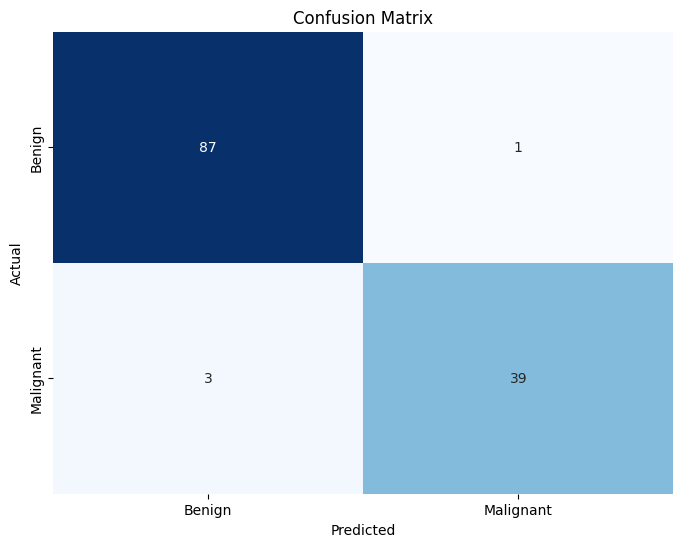

In [ ]:
import sys
import os
import random
import time
import gc
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms as T

# confusion matrix visualization
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# ══════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════
DATA_DIR = Path("BUSI_Jpeg")
CROPPED_DIR = Path("cropped_dataset")
SAVE_PATH= Path("classifier_best.pth")

IMG_SIZE = 64
CROP_SIZE = 128
BATCH_SIZE = 8
EPOCHS = 30
LR= 5e-4
WEIGHT_DECAY = 1e-4
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRAIN_RATIO = 0.80
TEST_RATIO = 0.20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ══════════════════════════════════════════════════════════════════════
#  STEP 1: CROP TUMOR REGIONS USING GT MASKS
# ══════════════════════════════════════════════════════════════════════

def crop_tumor_region(img_path, mask_path, save_size=128):
    """
    Load image + mask, zero out background, crop to bounding box of mask.
    """
    img  = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    if img.size != mask.size:
        mask = mask.resize(img.size, Image.NEAREST)

    img_np  = np.array(img)
    mask_np = np.array(mask)
    mask_bin = (mask_np > 127).astype(np.uint8)

    if mask_bin.sum() < 100:
        return img.resize((save_size, save_size))

    masked = img_np.copy()
    masked[mask_bin == 0] = 0

    rows = np.any(mask_bin, axis=1)
    cols = np.any(mask_bin, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    pad = 10
    rmin = max(0, rmin - pad)
    rmax = min(img_np.shape[0], rmax + pad)
    cmin = max(0, cmin - pad)
    cmax = min(img_np.shape[1], cmax + pad)

    cropped = Image.fromarray(masked[rmin:rmax, cmin:cmax])
    return cropped.resize((save_size, save_size))


def preprocess_dataset():

    print("=" * 60)
    print("  STEP 1: Cropping tumor regions using GT masks")
    print("=" * 60)

    total = 0
    for label_name in ["benign", "malignant"]:
        img_dir  = DATA_DIR / label_name
        mask_dir = DATA_DIR / f"{label_name}_mask"
        out_dir  = CROPPED_DIR / label_name
        os.makedirs(out_dir, exist_ok=True)

        count = 0
        for img_path in sorted(img_dir.glob("*.png")):
            stem = img_path.stem
            mask_path = mask_dir / f"{stem}_mask.png"
            if not mask_path.exists():
                continue
            cropped = crop_tumor_region(str(img_path), str(mask_path), CROP_SIZE)
            cropped.save(out_dir / f"{stem}.png")
            count += 1

        print(f"  {label_name}: {count} images cropped")
        total += count

    print(f"  Total: {total} cropped images saved to {CROPPED_DIR}/\n")


# ══════════════════════════════════════════════════════════════════════
#  STEP 2: MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════

class TumorClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


# ══════════════════════════════════════════════════════════════════════
#  STEP 3: DATA LOADING, TRANSFORMS & SPLITTING
# ══════════════════════════════════════════════════════════════════════

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def load_batch(samples, transform):
    """Load a batch of images from disk and apply transforms."""
    imgs, labels = [], []
    for path, label in samples:
        img = Image.open(path).convert("RGB")
        imgs.append(transform(img))
        labels.append(label)
    return torch.stack(imgs), torch.tensor(labels, dtype=torch.float32)


def gather_data():
    """Collect all (path, label) pairs from the cropped dataset."""
    data = []
    for f in os.listdir(CROPPED_DIR / "benign"):
        if f.endswith(".png"):
            data.append((str(CROPPED_DIR / "benign" / f), 0))
    for f in os.listdir(CROPPED_DIR / "malignant"):
        if f.endswith(".png"):
            data.append((str(CROPPED_DIR / "malignant" / f), 1))
    random.shuffle(data)
    return data


def stratified_split(data):
    """
    Stratified split into train (80%) and test (20%).
    Maintains the benign/malignant ratio in both sets.
    """
    benign    = [d for d in data if d[1] == 0]
    malignant = [d for d in data if d[1] == 1]
    random.shuffle(benign)
    random.shuffle(malignant)

    b_split = int(len(benign) * TRAIN_RATIO)
    m_split = int(len(malignant) * TRAIN_RATIO)

    train_set = benign[:b_split] + malignant[:m_split]
    test_set  = benign[b_split:] + malignant[m_split:]

    random.shuffle(train_set)
    random.shuffle(test_set)

    return train_set, test_set


# ══════════════════════════════════════════════════════════════════════
#  STEP 4: TRAINING LOOP
# ══════════════════════════════════════════════════════════════════════

def train():
    # --- Preprocess ---
    if not CROPPED_DIR.exists() or not any(CROPPED_DIR.iterdir()):
        preprocess_dataset()
    else:
        print(f"Using existing cropped dataset at {CROPPED_DIR}/\n")

    # --- Split ---
    data = gather_data()
    train_data, test_data = stratified_split(data)

    n_b = lambda d: sum(1 for x in d if x[1] == 0)
    n_m = lambda d: sum(1 for x in d if x[1] == 1)

    print("=" * 60)
    print("  DATA SPLIT (Stratified 80/20)")
    print("=" * 60)
    print(f"  {'Set':<10} {'Total':>6} {'Benign':>8} {'Malignant':>10}")
    print(f"  {'─' * 36}")
    print(f"  {'Train':<10} {len(train_data):>6} {n_b(train_data):>8} {n_m(train_data):>10}")
    print(f"  {'Test':<10} {len(test_data):>6} {n_b(test_data):>8} {n_m(test_data):>10}")
    print()

    # --- Model ---
    model = TumorClassifier().to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model parameters: {total_params:,}")
    print(f"  Device: {DEVICE}\n")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=3, factor=0.5
    )

    # --- Train ---
    best_acc = 0.0
    best_epoch = 0

    print("=" * 60)
    print("  TRAINING")
    print("=" * 60)
    print(f"  {'Epoch':>5} {'Time':>5} {'Train Loss':>11} {'Train Acc':>10} {'LR':>10}")
    print(f"  {'-' * 45}")

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        model.train()
        random.shuffle(train_data)
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for i in range(0, len(train_data), BATCH_SIZE):
            batch = train_data[i:i + BATCH_SIZE]
            imgs, labels = load_batch(batch, train_transform)
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs).squeeze(1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            train_correct += (preds == labels.long()).sum().item()
            train_total += labels.size(0)
            del imgs, labels, outputs, loss

        tl = train_loss / train_total
        ta = train_correct / train_total
        scheduler.step(tl)
        dt = time.time() - t0
        lr_now = optimizer.param_groups[0]["lr"]

        # Quick check on test set to track best model (no data leakage —
        # test transform has no augmentation, and test data is never
        # used for gradient updates or scheduler decisions)
        model.eval()
        test_correct = 0
        with torch.no_grad():
            for i in range(0, len(test_data), BATCH_SIZE):
                batch = test_data[i:i + BATCH_SIZE]
                imgs, labels = load_batch(batch, test_transform)
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs).squeeze(1)
                preds = (torch.sigmoid(outputs) > 0.5).long()
                test_correct += (preds == labels.long()).sum().item()
                del imgs, labels, outputs
        test_acc = test_correct / len(test_data)

        tag = ""
        if test_acc > best_acc:
            best_acc = test_acc
            best_epoch = epoch
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "best_test_acc": best_acc,
                "img_size": IMG_SIZE,
                "classes": ["benign", "malignant"],
            }, str(SAVE_PATH))
            tag = " ← saved"

        print(
            f"  {epoch:3d}   {dt:4.0f}s   {tl:10.4f}   {ta:9.3f}   "
            f"{lr_now:.2e}  |  test_acc: {test_acc:.3f}{tag}"
        )
        sys.stdout.flush()
        gc.collect()

    print(f"\n  Best test accuracy during training: {best_acc:.3f} (epoch {best_epoch})")
    print(f"  Model saved to: {SAVE_PATH}\n")

    # ── Final evaluation on test set with best model ──
    evaluate_test(test_data)


# ══════════════════════════════════════════════════════════════════════
#  STEP 5: TEST SET EVALUATION
# ══════════════════════════════════════════════════════════════════════

def evaluate_test(test_data):
    """Load best checkpoint and evaluate on the test set with full metrics."""
    print("=" * 60)
    print("  TEST SET EVALUATION (best checkpoint)")
    print("=" * 60)

    # Load best model
    ckpt = torch.load(str(SAVE_PATH), map_location=DEVICE, weights_only=False)
    model = TumorClassifier().to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for i in range(0, len(test_data), BATCH_SIZE):
            batch = test_data[i:i + BATCH_SIZE]
            imgs, labels = load_batch(batch, test_transform)
            imgs = imgs.to(DEVICE)

            outputs = model(imgs).squeeze(1)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).long()

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.long().tolist())
            all_probs.extend(probs.cpu().tolist())

            del imgs, labels, outputs

    # --- Confusion Matrix ---
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    accuracy  = (tp + tn) / len(all_labels) if all_labels else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print()
    print(f"  Confusion Matrix:")
    print(f"  {'':>20} {'Pred Benign':>13} {'Pred Malignant':>15}")
    print(f"  {'Actual Benign':>20} {tn:>13} {fp:>15}")
    print(f"  {'Actual Malignant':>20} {fn:>13} {tp:>15}")
    print()
    print(f"  Accuracy:    {accuracy:.4f}  ({tp + tn}/{len(all_labels)})")
    print(f"  Precision:   {precision:.4f}")
    print(f"  Recall:      {recall:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print()
    print(f"  (Positive class = Malignant)")
    print("=" * 60)

    # --- Plot Confusion Matrix ---
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


# ══════════════════════════════════════════════════════════════════════
#  STEP 6: INFERENCE HELPER
# ══════════════════════════════════════════════════════════════════════

def predict(image_path, mask_path=None, model_path="classifier_best.pth"):
    """
    Classify a single image as benign or malignant.

    Args:
        image_path: Path to the input image
        mask_path:  Optional path to a binary mask (white=tumor)
        model_path: Path to the trained checkpoint

    Returns:
        dict with keys: label, confidence, probability
    """
    img = Image.open(image_path).convert("RGB")

    if mask_path:
        mask = Image.open(mask_path).convert("L")
        if img.size != mask.size:
            mask = mask.resize(img.size, Image.NEAREST)
        img_np = np.array(img)
        mask_np = np.array(mask)
        mask_bin = (mask_np > 127).astype(np.uint8)

        if mask_bin.sum() >= 100:
            masked = img_np.copy()
            masked[mask_bin == 0] = 0
            rows = np.any(mask_bin, axis=1)
            cols = np.any(mask_bin, axis=0)
            rmin, rmax = np.where(rows)[0][[0, -1]]
            cmin, cmax = np.where(cols)[0][[0, -1]]
            pad = 10
            rmin = max(0, rmin - pad)
            rmax = min(img_np.shape[0], rmax + pad)
            cmin = max(0, cmin - pad)
            cmax = min(img_np.shape[1], cmax + pad)
            img = Image.fromarray(masked[rmin:rmax, cmin:cmax])

    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_arr = np.array(img_resized, dtype=np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_arr = (img_arr - mean) / std
    img_tensor = torch.from_numpy(img_arr.astype(np.float32)).permute(2, 0, 1).unsqueeze(0)

    ckpt = torch.load(model_path, map_location="cpu", weights_only=False)
    model = TumorClassifier()
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    with torch.no_grad():
        logit = model(img_tensor).squeeze()
        prob = torch.sigmoid(logit).item()

    label = "Malignant" if prob > 0.5 else "Benign"
    confidence = prob if prob > 0.5 else (1.0 - prob)

    return {
        "label": label,
        "confidence": round(confidence, 4),
        "probability": {
            "benign": round(1.0 - prob, 4),
            "malignant": round(prob, 4),
        },
    }


# ══════════════════════════════════════════════════════════════════════
#  MAIN
# ══════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    if len(sys.argv) > 1 and sys.argv[1] == "predict":
        # Usage: python train_classifier.py predict <image_path> [mask_path]
        img_path = sys.argv[2]
        msk_path = sys.argv[3] if len(sys.argv) > 3 else None
        result = predict(img_path, msk_path)
        print(f"Prediction: {result['label']} ({result['confidence']:.1%})")
        print(f"  Benign:    {result['probability']['benign']:.1%}")
        print(f"  Malignant: {result['probability']['malignant']:.1%}")
    else:
        train()